## Image Analysis

1. Compute Signal to noise ratio for all planes
2. Characterize Zones from (1) and define 3-5 Zones that differ

In [35]:
# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
from skimage import io
import sys
sys.path.append(str(BASE_DIR / 'src'))
import pandas as pd

In [3]:
# read the images
cnx = io.imread(BASE_DIR / 'data/raw/corrected_images/cnx43.tif')

#### Compare images across z-plane

In [40]:
import numpy as np
import matplotlib.pyplot as plt


def plot_every_nth_plane(cnx, step=30, mean_intensity=None, cmap="gray", n_cols=6):
    """
    Plot every Nth plane in the stack for direct visual comparison
    across the full depth range.

    Parameters
    ----------
    cnx : np.ndarray
        3D raw image stack, shape (z, y, x).
    step : int
        Interval between sampled planes (e.g. 30 -> planes 0, 30, 60, ...).
    mean_intensity : np.ndarray, optional
        Per-plane mean intensity values, shown in subplot titles if provided.
    cmap : str
        Colormap for displaying the planes.
    n_cols : int
        Number of columns in the grid.
    """
    n_planes_total = cnx.shape[0]
    sample_planes = list(range(0, n_planes_total, step))
    n_samples = len(sample_planes)

    n_rows = int(np.ceil(n_samples / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, z in enumerate(sample_planes):
        ax = axes[i]
        ax.imshow(cnx[z], cmap=cmap)

        title = f"z={z}"
        if mean_intensity is not None and not np.isnan(mean_intensity[z]):
            title += f"\nI={mean_intensity[z]:.0f}"
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    for j in range(len(sample_planes), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Every {step}th plane (n={n_samples})", fontsize=12)
    plt.tight_layout()
    plt.show()

    return fig



In [37]:
pwd

'/home/rck292/Project/notebooks'

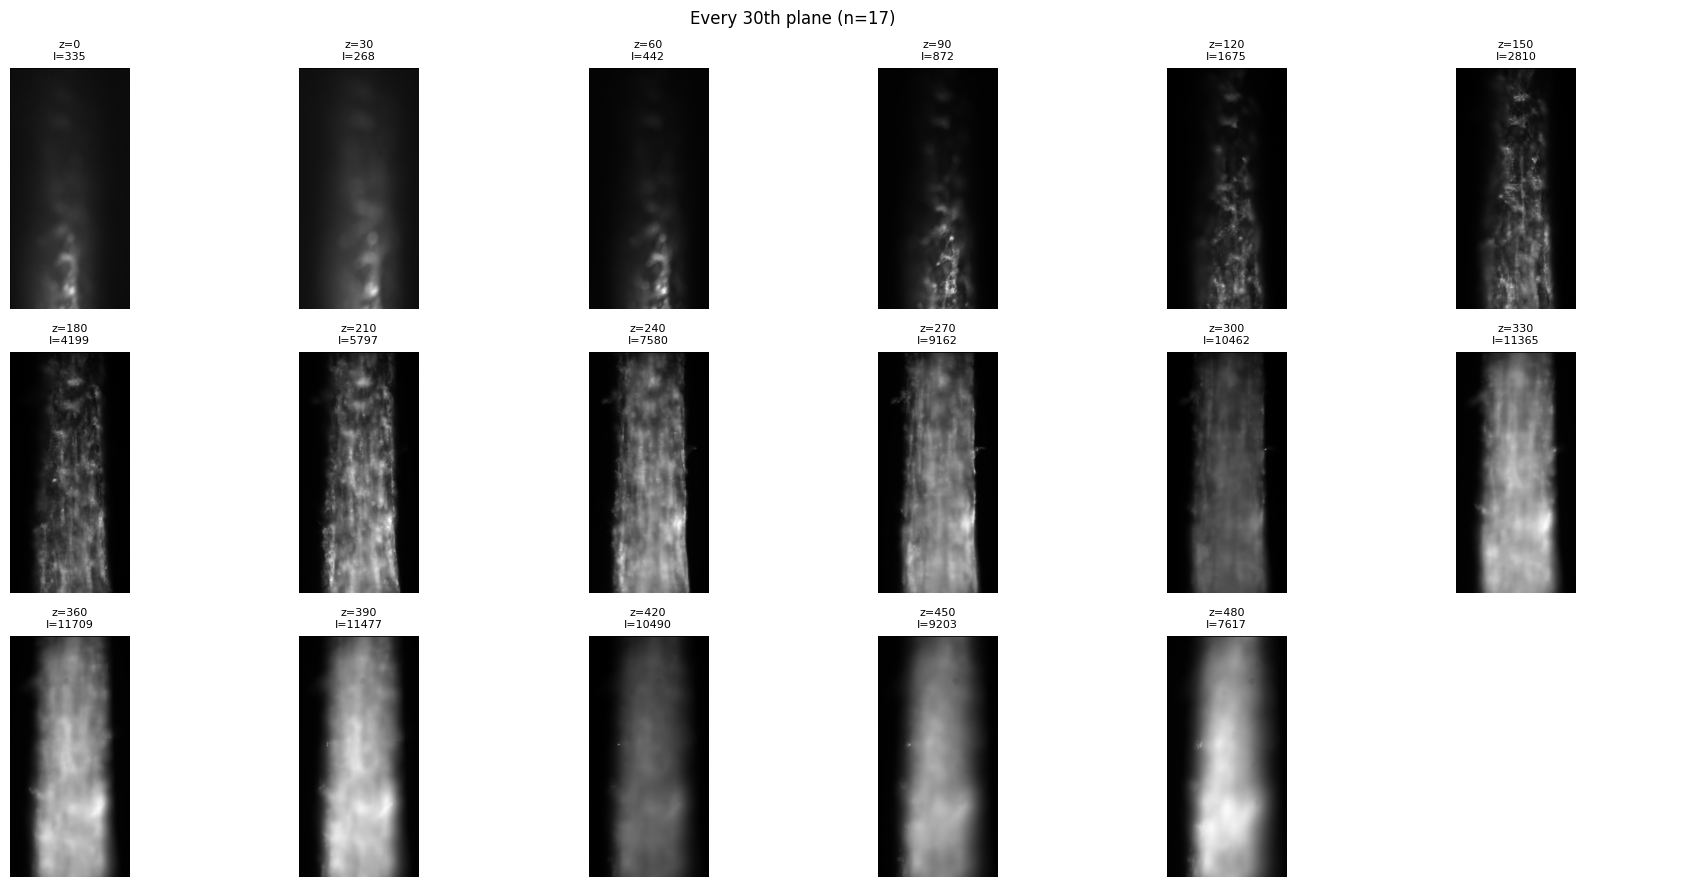

In [42]:
every_plane = plot_every_nth_plane(cnx, step=30, mean_intensity=mean_intensity)
# every_plane.savefig(BASE_DIR / 'results/every_30_plane.png') 


#### Compute Mean Fluorescence Signal across planes and derive Zones

In [53]:
def plot_mean_intensity_zprofile(cnx, voxel_size_z=0.766):
    """Diagnostic: plot mean intensity per plane to check for periodic
    brightness artifacts that could be confounding sharpness metrics."""
    mean_intensity = np.array([cnx[z].astype(np.float32).mean() for z in range(cnx.shape[0])])

    z_indices = np.arange(len(mean_intensity))
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(z_indices, mean_intensity, linewidth=1, color="seagreen")
    ax1.set_xlabel("Z-plane index")
    ax1.set_ylabel("Mean intensity")
    ax1.set_title("Mean fluorescence intensity across z-planes")
    ax1.grid(alpha=0.3)

    ax2 = ax1.secondary_xaxis(
        "top", functions=(lambda z: z * voxel_size_z, lambda um: um / voxel_size_z)
    )
    ax2.set_xlabel("Depth (µm)")
    plt.tight_layout()
    plt.show()

    return mean_intensity, fig

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


def detect_intensity_zones(mean_intensity, smooth_window=21, smooth_poly=3,
                             slope_threshold=None, min_zone_length=15):
    """
    Split a per-plane mean intensity profile into logical zones based on
    local slope (rising / plateau / falling), rather than peak/trough
    detection — appropriate for a smooth, largely single-peaked profile.

    Parameters
    ----------
    mean_intensity : np.ndarray
        1D array of per-plane mean intensity values.
    smooth_window : int
        Window length for Savitzky-Golay smoothing (must be odd).
    smooth_poly : int
        Polynomial order for the smoothing filter.
    slope_threshold : float or None
        Slope magnitude (intensity units per plane) below which a point
        is classified as "plateau" rather than rising/falling. If None,
        it's set automatically as 5% of the max absolute slope in the
        smoothed curve.
    min_zone_length : int
        Minimum number of planes for a zone to be kept on its own;
        shorter zones get merged into their largest neighbor. Avoids
        tiny spurious zones from local slope noise.

    Returns
    -------
    boundaries : np.ndarray
        Z-plane indices where zones split (includes 0 and last index).
    labels : list of str
        One label per zone: "rising", "plateau", or "falling".
    smoothed : np.ndarray
        The smoothed intensity curve used for detection.
    """
    n = len(mean_intensity)
    z_all = np.arange(n)

    valid_mask = ~np.isnan(mean_intensity)
    interpolated = np.interp(z_all, z_all[valid_mask], mean_intensity[valid_mask])

    smoothed = savgol_filter(interpolated, window_length=smooth_window,
                               polyorder=smooth_poly)
    slope = np.gradient(smoothed)

    if slope_threshold is None:
        slope_threshold = 0.05 * np.max(np.abs(slope))

    # Classify each plane by slope sign/magnitude
    point_labels = np.where(slope > slope_threshold, "rising",
                    np.where(slope < -slope_threshold, "falling", "plateau"))

    # Collapse consecutive identical labels into zone segments
    change_points = np.where(point_labels[1:] != point_labels[:-1])[0] + 1
    raw_boundaries = np.concatenate([[0], change_points, [n]])

    segments = []
    for i in range(len(raw_boundaries) - 1):
        start, end = raw_boundaries[i], raw_boundaries[i + 1]
        segments.append([start, end, point_labels[start]])

    # Merge short segments into whichever neighbor is more similar in slope
    # sign (repeat until no short segments remain, since merges can create
    # new short-neighbor situations)
    changed = True
    while changed:
        changed = False
        for i, (start, end, label) in enumerate(segments):
            if end - start < min_zone_length and len(segments) > 1:
                if i == 0:
                    merge_with = 1
                elif i == len(segments) - 1:
                    merge_with = i - 1
                else:
                    # Merge with whichever neighbor is longer (more "established")
                    left_len = segments[i - 1][1] - segments[i - 1][0]
                    right_len = segments[i + 1][1] - segments[i + 1][0]
                    merge_with = i - 1 if left_len >= right_len else i + 1

                lo = min(i, merge_with)
                hi = max(i, merge_with)
                new_start = segments[lo][0]
                new_end = segments[hi][1]
                # Keep the label of the longer of the two merged segments
                new_label = segments[lo][2] if (segments[lo][1] - segments[lo][0]) >= \
                                                (segments[hi][1] - segments[hi][0]) else segments[hi][2]
                segments[lo:hi + 1] = [[new_start, new_end, new_label]]
                changed = True
                break

    boundaries = np.array([seg[0] for seg in segments] + [segments[-1][1] - 1])
    labels = [seg[2] for seg in segments]

    return boundaries, labels, smoothed


import numpy as np
import matplotlib.pyplot as plt


def plot_intensity_zones(mean_intensity, boundaries, labels, smoothed, voxel_size_z=0.766):
    """Plot the mean intensity profile with detected zone boundaries and labels.
    Colors are colorblind-safe (Okabe-Ito palette) and are assigned per base
    category (e.g. "plateau-1" and "plateau-3" share a color family), with
    shading intensity varying across sub-zones so they remain distinguishable.
    """
    z_indices = np.arange(len(mean_intensity))

    # Okabe-Ito colorblind-safe palette
    base_color_map = {
        "rising": "#0072B2",   # blue
        "plateau": "#E69F00",  # orange
        "falling": "#009E73",  # green
    }
    fallback_colors = ["#CC79A7", "#56B4E9", "#D55E00", "#F0E442"]  # extra safe colors if needed

    def get_base_label(label):
        # Strip "-N" suffix if present (e.g. "plateau-2" -> "plateau")
        return label.rsplit("-", 1)[0] if "-" in label and label.rsplit("-", 1)[1].isdigit() else label

    # Assign a color to every unique base label encountered, in order of appearance
    unique_bases = []
    for lbl in labels:
        base = get_base_label(lbl)
        if base not in unique_bases:
            unique_bases.append(base)

    zone_base_colors = {}
    fallback_idx = 0
    for base in unique_bases:
        if base in base_color_map:
            zone_base_colors[base] = base_color_map[base]
        else:
            zone_base_colors[base] = fallback_colors[fallback_idx % len(fallback_colors)]
            fallback_idx += 1

    # For sub-zones within the same base category, vary alpha so they're
    # visually distinguishable from each other while staying in the same
    # color family
    base_counts = {}
    for lbl in labels:
        base = get_base_label(lbl)
        base_counts[base] = base_counts.get(base, 0) + 1

    base_running_idx = {base: 0 for base in unique_bases}

    fig, ax1 = plt.subplots(figsize=(11, 5))

    ax1.plot(z_indices, mean_intensity, linewidth=1, color="lightgray",
              label="Raw mean intensity", zorder=1)
    ax1.plot(z_indices, smoothed, linewidth=2, color="black",
              label="Smoothed", zorder=2)

    y_max = max(np.nanmax(mean_intensity), np.nanmax(smoothed))

    for i in range(len(boundaries) - 1):
        z_start, z_end = boundaries[i], boundaries[i + 1]
        base = get_base_label(labels[i])
        color = zone_base_colors[base]

        n_subzones_in_base = base_counts[base]
        idx_in_base = base_running_idx[base]
        base_running_idx[base] += 1

        # Vary alpha across sub-zones of the same base (0.12 to 0.30 range)
        # so repeated sub-zones of one category are still distinguishable
        if n_subzones_in_base > 1:
            alpha = 0.12 + 0.18 * (idx_in_base / (n_subzones_in_base - 1))
        else:
            alpha = 0.18

        ax1.axvspan(z_start, z_end, color=color, alpha=alpha)
        mid = (z_start + z_end) / 2
        ax1.text(mid, y_max * 1.02, f"Zone {i+1}\n({labels[i]})",
                  ha="center", va="bottom", fontsize=7, color=color, rotation=0)

    ax1.set_xlabel("Z-plane index")
    ax1.set_ylabel("Mean intensity")
    ax1.set_title("Detected intensity zones across z-depth")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)
    ax1.set_ylim(top=y_max * 1.25)  # leave room for zone labels above the curve

    ax2 = ax1.secondary_xaxis(
        "top", functions=(lambda z: z * voxel_size_z, lambda um: um / voxel_size_z)
    )
    ax2.set_xlabel("Depth (µm)")

    plt.tight_layout()
    plt.show()

    print(f"Detected {len(boundaries) - 1} zones:")
    for i in range(len(boundaries) - 1):
        print(f"  Zone {i+1} ({labels[i]}): planes {boundaries[i]}–{boundaries[i+1]}")


    return fig 



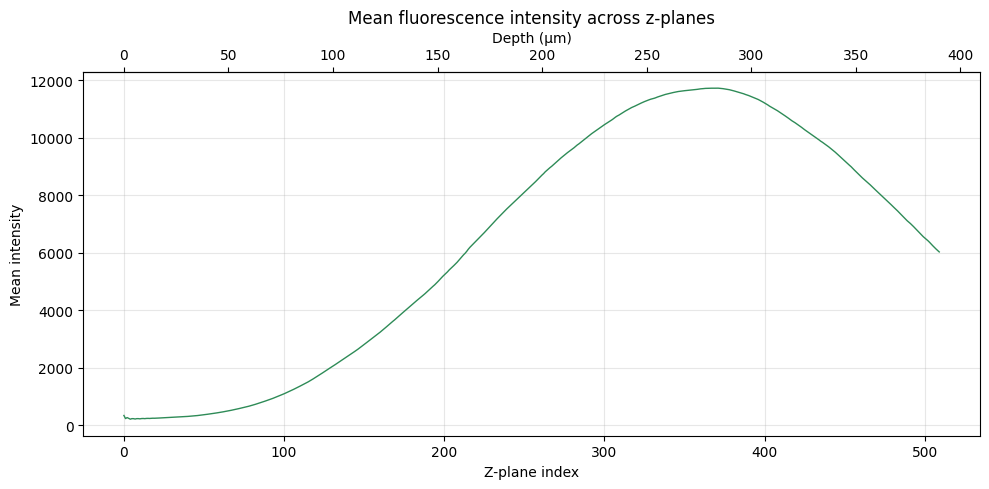

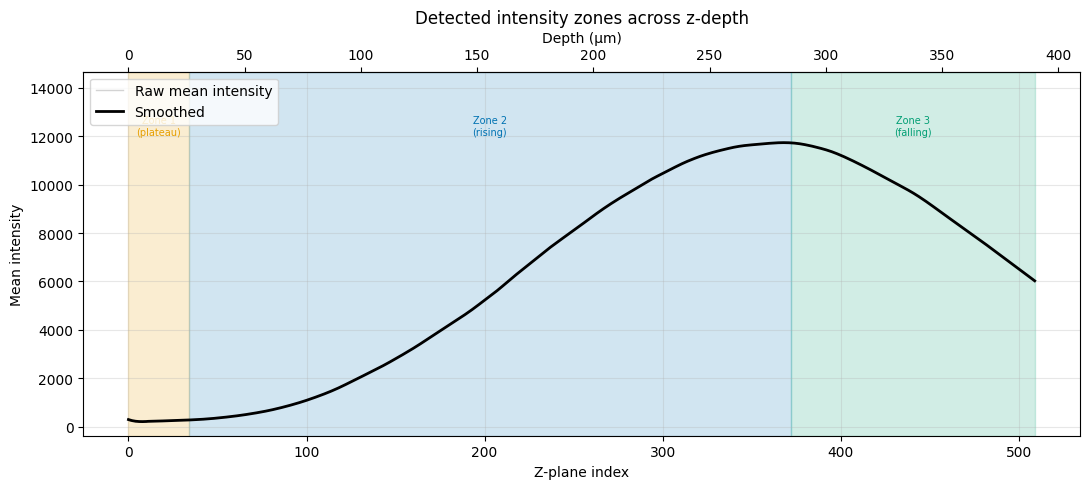

Detected 3 zones:
  Zone 1 (plateau): planes 0–34
  Zone 2 (rising): planes 34–372
  Zone 3 (falling): planes 372–509


In [54]:
mean_intensity, mean_intensity_fig = plot_mean_intensity_zprofile(cnx)  # or however you stored it
boundaries, labels, smoothed = detect_intensity_zones(mean_intensity)
plot_intensity_zones(mean_intensity, boundaries, labels, smoothed)

# mean_intensity_fig.savefig(BASE_DIR / 'results/mean_intensity_all_planes.png') 

In [28]:
import numpy as np


def subdivide_zone_equal(boundaries, labels, zone_index, n_subzones=4):
    """
    Subdivide one existing zone into n equal-width sub-zones.

    Parameters
    ----------
    boundaries : np.ndarray
        Current zone boundaries.
    labels : list of str
        Current zone labels.
    zone_index : int
        Index of the zone to subdivide (0-based, matches "Zone N" - 1
        printed by detect_intensity_zones/plot_intensity_zones).
    n_subzones : int
        Number of equal-sized sub-zones to split this zone into.

    Returns
    -------
    new_boundaries : np.ndarray
        Updated boundary array with the target zone replaced by
        n_subzones new boundaries.
    new_labels : list of str
        Updated labels, with sub-zones labeled e.g. "rising-1", ..., "rising-4".
    """
    z_start, z_end = boundaries[zone_index], boundaries[zone_index + 1]
    base_label = labels[zone_index]

    # Equal-width split points across the zone's range
    split_points = np.linspace(z_start, z_end, n_subzones + 1).astype(int)
    split_points = np.unique(split_points)
    n_actual_subzones = len(split_points) - 1

    new_zone_labels = [f"{base_label}-{i+1}" for i in range(n_actual_subzones)]

    new_boundaries = np.concatenate([
        boundaries[:zone_index],
        split_points,
        boundaries[zone_index + 2:]
    ])
    new_boundaries = np.unique(new_boundaries)

    new_labels = labels[:zone_index] + new_zone_labels + labels[zone_index + 1:]

    return new_boundaries, new_labels




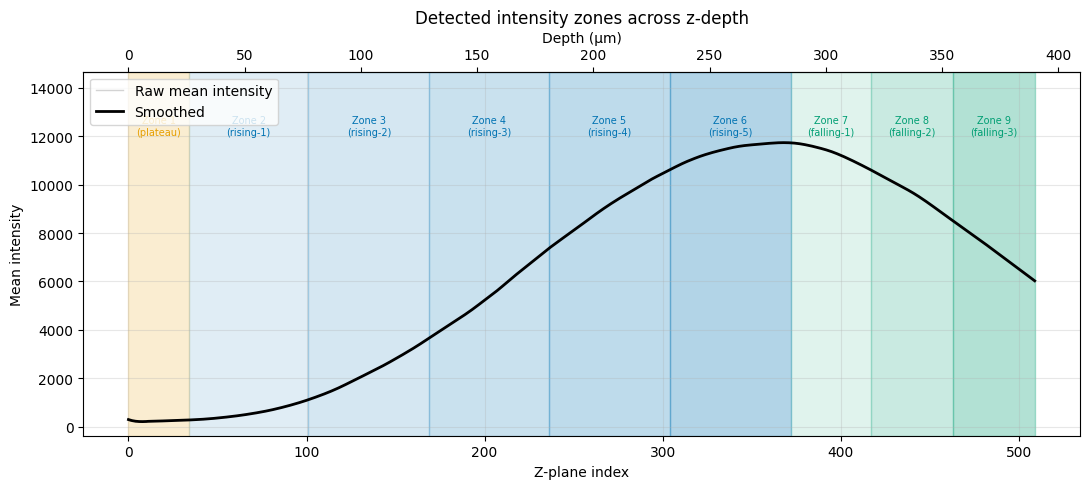

Detected 9 zones:
  Zone 1 (plateau): planes 0–34
  Zone 2 (rising-1): planes 34–101
  Zone 3 (rising-2): planes 101–169
  Zone 4 (rising-3): planes 169–236
  Zone 5 (rising-4): planes 236–304
  Zone 6 (rising-5): planes 304–372
  Zone 7 (falling-1): planes 372–417
  Zone 8 (falling-2): planes 417–463
  Zone 9 (falling-3): planes 463–509


In [59]:
# Usage: split Zone 2 (zone_index=1) into 4 equal sub-zones
boundaries, labels, smoothed = detect_intensity_zones(mean_intensity)
boundaries, labels = subdivide_zone_equal(boundaries, labels, zone_index=1, n_subzones=5) # split zone into subzones
boundaries, labels = subdivide_zone_equal(boundaries, labels, zone_index=6, n_subzones=3) # split zone into subzones
fig_intensity_zones = plot_intensity_zones(mean_intensity, boundaries, labels, smoothed)
# fig_intensity_zones.savefig(BASE_DIR / 'results/intensity_zones.png')

In [66]:
import numpy as np
import matplotlib.pyplot as plt


def plot_zone_samples_labeled(cnx, boundaries, labels, mean_intensity=None, cmap="gray"):
    """
    Plot one representative plane (middle of zone) from each zone,
    labeled with the zone's name (e.g. "rising", "plateau-2").

    Parameters
    ----------
    cnx : np.ndarray
        3D raw image stack, shape (z, y, x).
    boundaries : np.ndarray
        Zone boundary z-indices.
    labels : list of str
        One label per zone (length = len(boundaries) - 1).
    mean_intensity : np.ndarray, optional
        Per-plane mean intensity values, shown in subplot titles if provided.
    cmap : str
        Colormap for displaying the planes.
    """
    n_zones = len(boundaries) - 1
    sample_planes = [int((boundaries[i] + boundaries[i + 1]) // 2) for i in range(n_zones)]

    n_cols = min(4, n_zones)
    n_rows = int(np.ceil(n_zones / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, z in enumerate(sample_planes):
        ax = axes[i]
        ax.imshow(cnx[z], cmap=cmap)

        title = f"Zone {i+1}: {labels[i]}\n(z={z})"
        if mean_intensity is not None and not np.isnan(mean_intensity[z]):
            title += f"\nIntensity={mean_intensity[z]:.0f}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    for j in range(len(sample_planes), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return fig, sample_planes




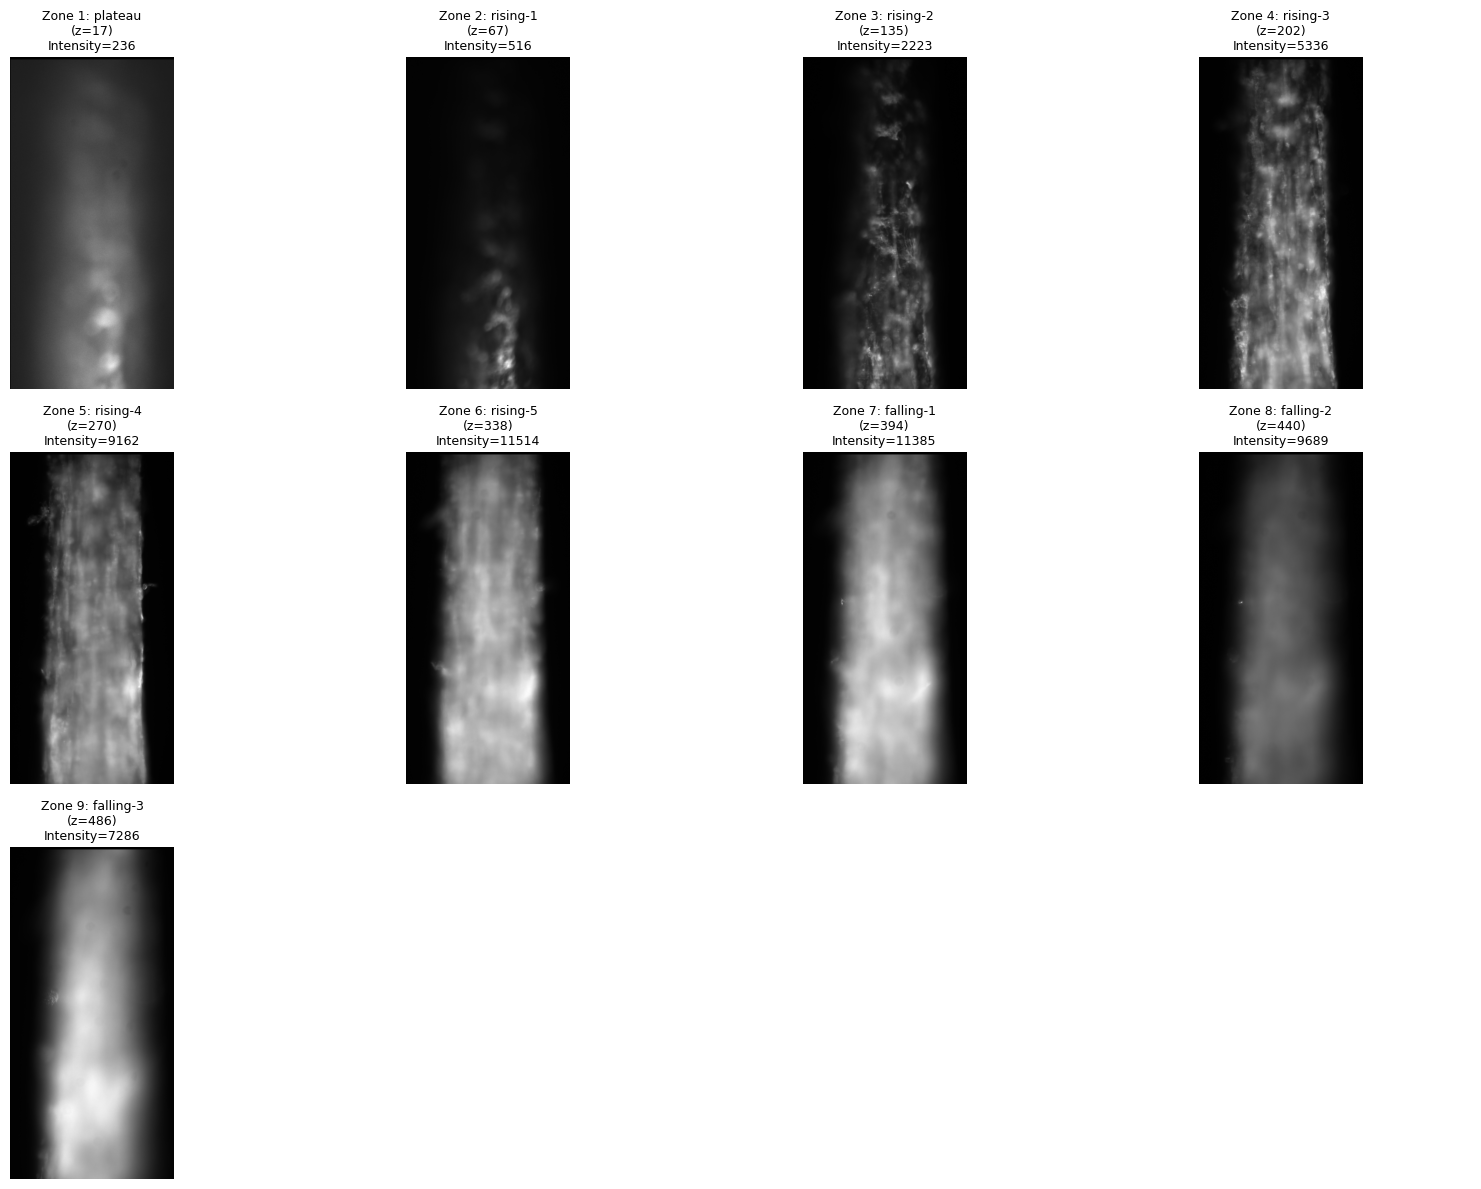

In [67]:
# boundaries, labels, smoothed = detect_intensity_zones(mean_intensity)
# boundaries, labels = subdivide_zone_equal(boundaries, labels, zone_index=1, n_subzones=4)
fig_zone_samples, sample_planes = plot_zone_samples_labeled(cnx, boundaries, labels, mean_intensity=mean_intensity)
# mean_intensity, boundaries, labels, smoothed
# fig_zone_samples.savefig(BASE_DIR / 'results/zone_samples_fig.png')


In [68]:
import csv


def save_zone_samples_csv(boundaries, labels, mean_intensity=None, filepath="zone_samples.csv"):
    """
    Save zone boundaries and representative sample planes to a CSV file.

    Parameters
    ----------
    boundaries : np.ndarray
        Zone boundary z-indices.
    labels : list of str
        One label per zone.
    mean_intensity : np.ndarray, optional
        Per-plane mean intensity values, included as a column if provided.
    filepath : str
        Output CSV path.
    """
    n_zones = len(boundaries) - 1
    sample_planes = [int((boundaries[i] + boundaries[i + 1]) // 2) for i in range(n_zones)]

    with open(filepath, "w", newline="") as f:
        writer = csv.writer(f)
        header = ["zone_number", "zone_label", "z_start", "z_end", "sample_plane"]
        if mean_intensity is not None:
            header.append("sample_plane_intensity")
        writer.writerow(header)

        for i in range(n_zones):
            row = [i + 1, labels[i], boundaries[i], boundaries[i + 1], sample_planes[i]]
            if mean_intensity is not None:
                z = sample_planes[i]
                row.append(round(float(mean_intensity[z]), 2) if not np.isnan(mean_intensity[z]) else "")
            writer.writerow(row)

    print(f"Saved {n_zones} zones to {filepath}")




In [69]:
# Usage:
save_zone_samples_csv(boundaries, labels, mean_intensity=mean_intensity,
                        filepath="zone_samples.csv")

Saved 9 zones to zone_samples.csv
